In [6]:
import torch
import os
import json
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [7]:
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.001
TRAIN_DIR = "cifar3/train"
TEST_DIR = "cifar3/test"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Устройство:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

Устройство: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA: 12.1


In [8]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [9]:
class MyCifarDataset(Dataset):
    def __init__(self, path, train=True, transform=None):
        self.base_path = path
        self.path = os.path.join(path, "train" if train else "test")
        self.transform = transform

        with open(
            os.path.join(self.base_path, "format.json"),
            "r",
            encoding="utf-8"
        ) as fp:
            self.format = json.load(fp)

        self.class_to_idx = self.format["class_to_index"]
        self.classes = list(self.class_to_idx.keys())

        self.files = []
        self.targets = []

        for class_name, class_idx in self.class_to_idx.items():
            class_folder = os.path.join(self.path, class_name)

            for file_name in os.listdir(class_folder):
                self.files.append(os.path.join(class_name, file_name))
                self.targets.append(class_idx)

        self.length = len(self.files)

    def __getitem__(self, index):
        path_file = os.path.join(self.path, self.files[index])
        img = Image.open(path_file).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.targets[index], dtype=torch.long)

        return img, label

    def __len__(self):
        return self.length

In [10]:
BASE_DIR="cifar3"

train_dataset=MyCifarDataset(BASE_DIR,train=True,transform=train_transform)
test_dataset=MyCifarDataset(BASE_DIR,train=False,transform=test_transform)

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=0,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=True)

print("Классы:",train_dataset.classes)
print("Тренировочные изображения:",len(train_dataset))
print("Тестовые изображения:",len(test_dataset))

Классы: ['apple', 'bus', 'dolphin']
Тренировочные изображения: 1500
Тестовые изображения: 300


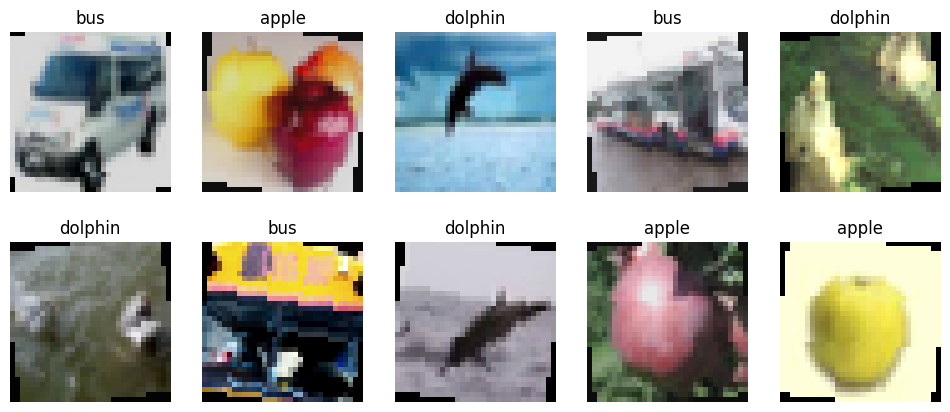

In [11]:
images,labels=next(iter(train_loader))
fig,axes=plt.subplots(2,5,figsize=(12,5))

for i,ax in enumerate(axes.flat):
    img=images[i]
    img=img/2+0.5
    np_img=img.permute(1,2,0).numpy()
    ax.imshow(np_img)
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.show()

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,3)
        )

    def forward(self,x):
        return self.classifier(self.features(x))

In [13]:
model=CNN().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=LEARNING_RATE)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.

In [14]:
train_losses=[]
train_accuracies=[]

for epoch in range(EPOCHS):
    model.train()
    running_loss=0.0
    correct=0
    total=0

    loop=tqdm(train_loader)

    for images,labels in loop:
        images=images.to(device,non_blocking=True)
        labels=labels.to(device,non_blocking=True)

        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()

        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()

        loop.set_description(f"Эпоха {epoch+1}/{EPOCHS}")
        loop.set_postfix(loss=loss.item(),accuracy=100*correct/total)

    epoch_loss=running_loss/len(train_loader)
    epoch_accuracy=100*correct/total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Эпоха {epoch+1}: Функция потерь={epoch_loss:.4f}, Точность={epoch_accuracy:.2f}%")

Эпоха 1/20: 100%|██████████| 6/6 [00:01<00:00,  3.74it/s, accuracy=57.5, loss=0.621]


Эпоха 1: Функция потерь=0.8366, Точность=57.53%


Эпоха 2/20: 100%|██████████| 6/6 [00:00<00:00,  6.02it/s, accuracy=86.7, loss=0.274]


Эпоха 2: Функция потерь=0.3432, Точность=86.73%


Эпоха 3/20: 100%|██████████| 6/6 [00:01<00:00,  5.88it/s, accuracy=89.4, loss=0.25] 


...

Эпоха 18: Функция потерь=0.0454, Точность=98.27%


Эпоха 19/20: 100%|██████████| 6/6 [00:01<00:00,  4.50it/s, accuracy=98.9, loss=0.037] 


Эпоха 19: Функция потерь=0.0360, Точность=98.93%


Эпоха 20/20: 100%|██████████| 6/6 [00:01<00:00,  4.70it/s, accuracy=98.5, loss=0.0408]

Эпоха 20: Функция потерь=0.0414, Точность=98.53%


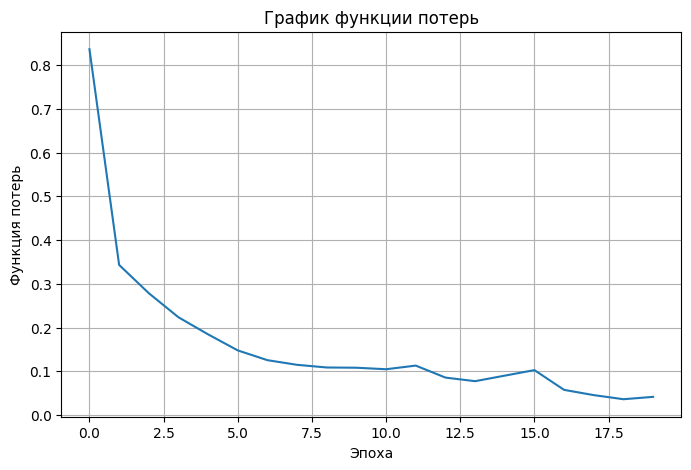

In [15]:
plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Функция потерь")
plt.grid()
plt.show()

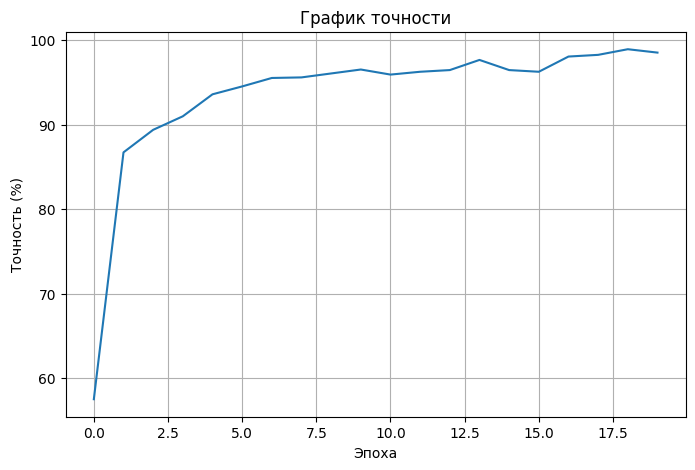

In [16]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies)
plt.title("График точности")
plt.xlabel("Эпоха")
plt.ylabel("Точность (%)")
plt.grid()
plt.show()

In [17]:
model.eval()
correct=0
total=0

with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device,non_blocking=True)
        labels=labels.to(device,non_blocking=True)
        outputs=model(images)
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()

test_accuracy=100*correct/total
print(f"Точность на тестовой выборке: {test_accuracy:.2f}%")

Точность на тестовой выборке: 96.00%


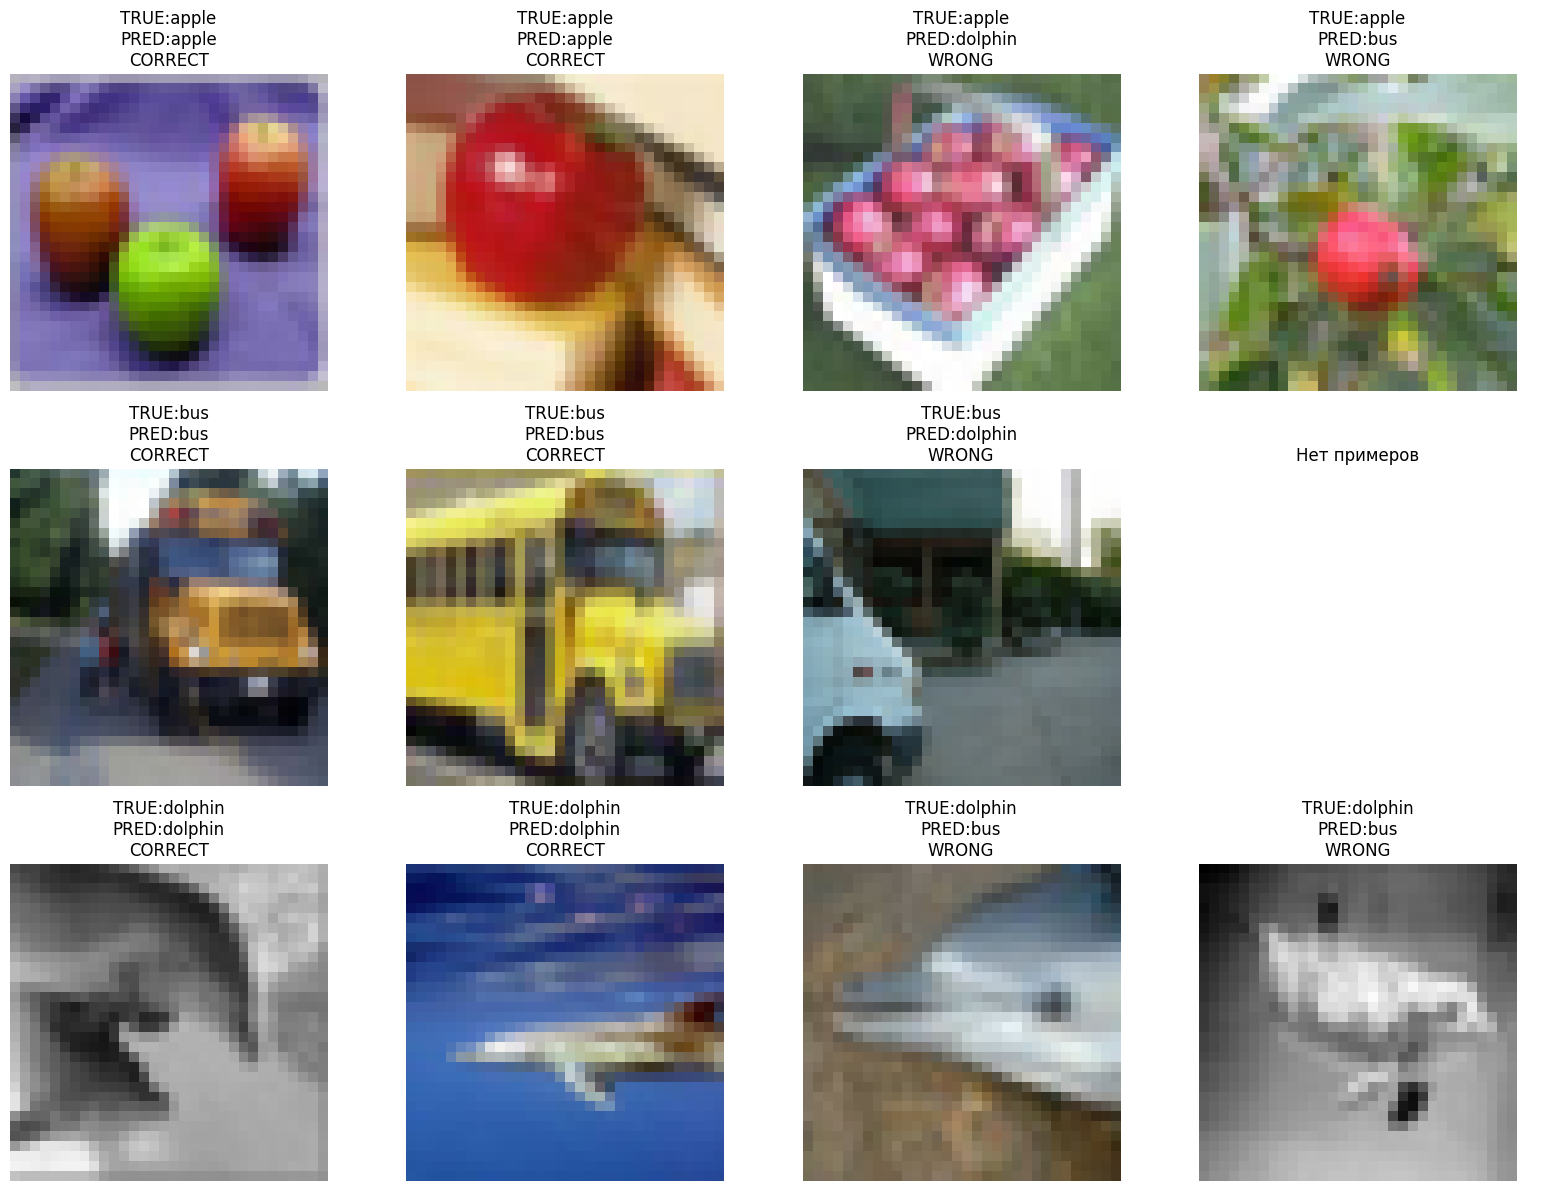

In [18]:
model.eval()
class_names=train_dataset.classes

results={c:{"correct":[],"wrong":[]} for c in class_names}

with torch.no_grad():
    for images,labels in test_loader:
        images_gpu=images.to(device)
        outputs=model(images_gpu)
        _,predicted=torch.max(outputs,1)

        for i in range(len(labels)):
            t=labels[i].item()
            p=predicted[i].item()

            t_name=class_names[t]
            p_name=class_names[p]

            img=images[i]

            if t==p:
                if len(results[t_name]["correct"])<2:
                    results[t_name]["correct"].append((img,p_name))
            else:
                if len(results[t_name]["wrong"])<2:
                    results[t_name]["wrong"].append((img,p_name))

fig,axes=plt.subplots(3,4,figsize=(16,12))

for r,cname in enumerate(class_names):
    ex=results[cname]["correct"]+results[cname]["wrong"]

    for col in range(4):
        ax=axes[r,col]

        if col<len(ex):
            img,pred=ex[col]
            img=img/2+0.5
            np_img=img.permute(1,2,0).numpy()

            ax.imshow(np_img)

            status="CORRECT" if pred==cname else "WRONG"

            ax.set_title(f"TRUE:{cname}\nPRED:{pred}\n{status}")
        else:
            ax.set_title("Нет примеров")

        ax.axis("off")

plt.tight_layout()
plt.show()